In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.models as models
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
trainTransform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    # transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

testTransform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

trainDir = "D:/SeniorProject/LLMImageLabels"
testDir = "D:/SeniorProject/CroppedImages"

trainDataset = ImageFolder(root=trainDir, transform=trainTransform)
testDataset = ImageFolder(root=testDir, transform=testTransform)
trainLoader = DataLoader(trainDataset, batch_size=32, shuffle=True)
testLoader = DataLoader(testDataset, batch_size=32, shuffle=True)

In [4]:
def evaluateModel(model, testLoader):
  
  model.eval()
  correct = 0
  total = 0
  # Testing predictions on test set generated earlier and returning the accuracy
  with torch.no_grad():
    for images, labels in testLoader:
      images, labels = images.to(device), labels.to(device)
      outputs = model(images)
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()
  accuracy = 100 * correct / total
  return accuracy

In [5]:
def trainModel(model, numEpochs):

    trainLosses = []
    trainAccuracies = []
    validLosses = []
    validAccuracies = []

    for epoch in range(numEpochs): 
        model.train()
        running_loss = 0.0
        correct = total = 0

        for i, data in enumerate(trainLoader, 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        trainLosses.append(running_loss / len(trainLoader))
        trainAccuracies.append(correct / total)

        model.eval()

        valLoss = 0
        correct = total = 0
        with torch.no_grad():
            for data in testLoader:
                images, labels = data
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                valLoss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        validLosses.append(valLoss / len(testLoader))
        validAccuracies.append(correct / total)
        print(f"Epoch {epoch + 1}/{numEpochs}, Train Loss: {trainLosses[-1]:.4f}, Train Accuracy: {trainAccuracies[-1]:.4f}, Validation Loss: {validLosses[-1]:.4f}, Validation Accuracy: {validAccuracies[-1]:.4f}")


    plt.plot(range(1, numEpochs + 1), trainLosses, label="Training Loss", color="blue")
    plt.plot(range(1, numEpochs + 1), validLosses, label="Validation Loss", color="orange")
    plt.plot(range(1, numEpochs + 1), validAccuracies, label="Validation Accuracy", color="green") # This is not working
    plt.xlabel("Epoch")
    plt.ylabel("Loss/Accuracy")
    plt.title("Statistics vs. Epochs")
    plt.legend()
    plt.show()
    
    return model

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5) 
        self.conv2 = nn.Conv2d(6, 16, 5)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(16 * 53 * 53, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 30)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [40]:
class BetterNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3) 
        self.conv2 = nn.Conv2d(16, 32, 3)
        self.conv3 = nn.Conv2d(32, 64, 3)

        self.bn1 = nn.BatchNorm2d(16)
        self.bn2 = nn.BatchNorm2d(32)
        self.bn3 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 26 * 26, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 30)
        self.fc4 = nn.Linear(30, 30)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x

Epoch 1/10, Train Loss: 3.1495, Train Accuracy: 0.1131, Validation Loss: 3.1575, Validation Accuracy: 0.1084
Epoch 2/10, Train Loss: 2.4390, Train Accuracy: 0.2980, Validation Loss: 3.0201, Validation Accuracy: 0.1289
Epoch 3/10, Train Loss: 1.8664, Train Accuracy: 0.4584, Validation Loss: 3.1310, Validation Accuracy: 0.1777
Epoch 4/10, Train Loss: 1.1948, Train Accuracy: 0.6607, Validation Loss: 3.6143, Validation Accuracy: 0.1768
Epoch 5/10, Train Loss: 0.5281, Train Accuracy: 0.8482, Validation Loss: 4.4190, Validation Accuracy: 0.1729
Epoch 6/10, Train Loss: 0.1443, Train Accuracy: 0.9633, Validation Loss: 5.4833, Validation Accuracy: 0.1748
Epoch 7/10, Train Loss: 0.0921, Train Accuracy: 0.9775, Validation Loss: 5.7866, Validation Accuracy: 0.1855
Epoch 8/10, Train Loss: 0.0425, Train Accuracy: 0.9921, Validation Loss: 6.2164, Validation Accuracy: 0.1748
Epoch 9/10, Train Loss: 0.0065, Train Accuracy: 0.9993, Validation Loss: 6.6113, Validation Accuracy: 0.1855
Epoch 10/10, Train 

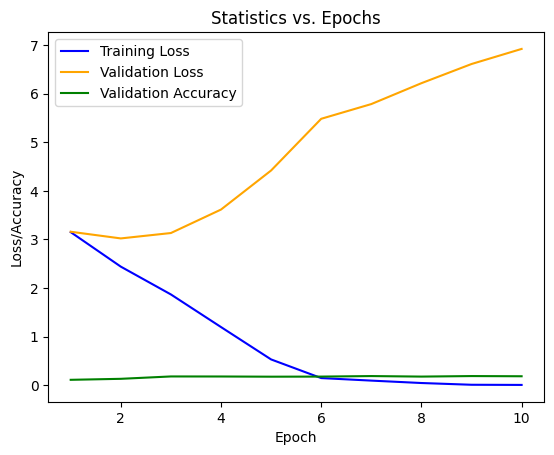

Accuracy: 18.1640625


In [34]:
model = Net().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
model = trainModel(model, 10)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy}")

Epoch 1/5, Train Loss: 2.5268, Train Accuracy: 0.2660, Validation Loss: 2.8327, Validation Accuracy: 0.1670
Epoch 2/5, Train Loss: 0.9785, Train Accuracy: 0.7256, Validation Loss: 3.9436, Validation Accuracy: 0.1777
Epoch 3/5, Train Loss: 0.1634, Train Accuracy: 0.9562, Validation Loss: 5.2411, Validation Accuracy: 0.1768
Epoch 4/5, Train Loss: 0.0256, Train Accuracy: 0.9941, Validation Loss: 6.1438, Validation Accuracy: 0.1699
Epoch 5/5, Train Loss: 0.0113, Train Accuracy: 0.9974, Validation Loss: 7.5627, Validation Accuracy: 0.1816


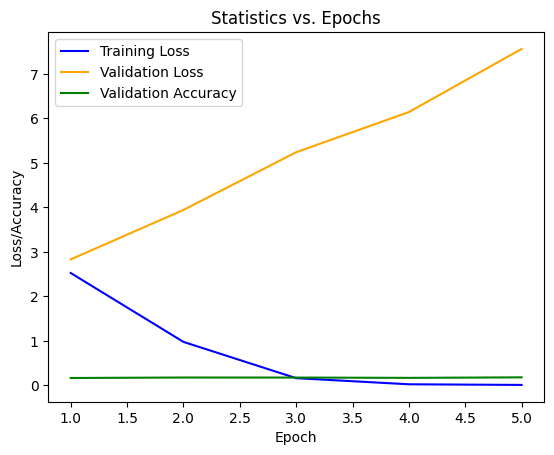

Accuracy: 18.1640625


In [39]:
model = Net().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model = trainModel(model, 5)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy}")

Epoch 1/15, Train Loss: 3.2947, Train Accuracy: 0.0764, Validation Loss: 3.3105, Validation Accuracy: 0.0739
Epoch 2/15, Train Loss: 2.9699, Train Accuracy: 0.1526, Validation Loss: 3.0391, Validation Accuracy: 0.1672
Epoch 3/15, Train Loss: 2.5881, Train Accuracy: 0.2364, Validation Loss: 2.7835, Validation Accuracy: 0.1846
Epoch 4/15, Train Loss: 2.3216, Train Accuracy: 0.2989, Validation Loss: 2.6612, Validation Accuracy: 0.2196
Epoch 5/15, Train Loss: 2.1565, Train Accuracy: 0.3478, Validation Loss: 2.6532, Validation Accuracy: 0.2264
Epoch 6/15, Train Loss: 1.9321, Train Accuracy: 0.4074, Validation Loss: 2.4743, Validation Accuracy: 0.2527
Epoch 7/15, Train Loss: 1.7113, Train Accuracy: 0.4709, Validation Loss: 2.3973, Validation Accuracy: 0.2595
Epoch 8/15, Train Loss: 1.5082, Train Accuracy: 0.5335, Validation Loss: 3.0984, Validation Accuracy: 0.2021
Epoch 9/15, Train Loss: 1.4825, Train Accuracy: 0.5522, Validation Loss: 2.3894, Validation Accuracy: 0.2867
Epoch 10/15, Train 

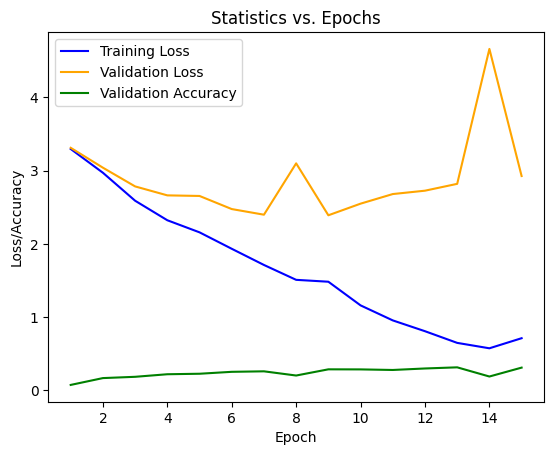

Accuracy: 31.000971817298346


In [43]:
model = BetterNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
model = trainModel(model, 15)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy}")

Epoch 1/20, Train Loss: 3.2114, Train Accuracy: 0.0999, Validation Loss: 3.1816, Validation Accuracy: 0.1030
Epoch 2/20, Train Loss: 2.7200, Train Accuracy: 0.1979, Validation Loss: 2.8863, Validation Accuracy: 0.1642
Epoch 3/20, Train Loss: 2.4562, Train Accuracy: 0.2572, Validation Loss: 2.7115, Validation Accuracy: 0.1914
Epoch 4/20, Train Loss: 2.2501, Train Accuracy: 0.3145, Validation Loss: 2.5796, Validation Accuracy: 0.2089
Epoch 5/20, Train Loss: 2.0608, Train Accuracy: 0.3631, Validation Loss: 2.5688, Validation Accuracy: 0.2187
Epoch 6/20, Train Loss: 1.8395, Train Accuracy: 0.4266, Validation Loss: 2.5328, Validation Accuracy: 0.2235
Epoch 7/20, Train Loss: 1.6371, Train Accuracy: 0.4870, Validation Loss: 2.4498, Validation Accuracy: 0.2478
Epoch 8/20, Train Loss: 1.4446, Train Accuracy: 0.5395, Validation Loss: 2.4721, Validation Accuracy: 0.2653
Epoch 9/20, Train Loss: 1.2433, Train Accuracy: 0.6005, Validation Loss: 2.6775, Validation Accuracy: 0.2585
Epoch 10/20, Train 

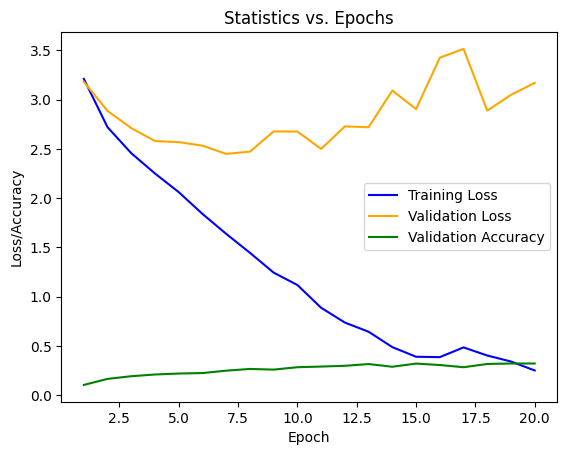

Accuracy: 32.06997084548105


In [44]:
model = BetterNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
model = trainModel(model, 20)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy}")

# No Data Augmentation

Epoch 1/60, Train Loss: 3.3713, Train Accuracy: 0.0630, Validation Loss: 3.3959, Validation Accuracy: 0.0709
Epoch 2/60, Train Loss: 3.1168, Train Accuracy: 0.0980, Validation Loss: 3.1187, Validation Accuracy: 0.0884
Epoch 3/60, Train Loss: 2.8991, Train Accuracy: 0.1212, Validation Loss: 2.9831, Validation Accuracy: 0.1069
Epoch 4/60, Train Loss: 2.7622, Train Accuracy: 0.1568, Validation Loss: 2.9606, Validation Accuracy: 0.1186
Epoch 5/60, Train Loss: 2.6159, Train Accuracy: 0.2037, Validation Loss: 2.8259, Validation Accuracy: 0.1827
Epoch 6/60, Train Loss: 2.4967, Train Accuracy: 0.2389, Validation Loss: 2.8011, Validation Accuracy: 0.1905
Epoch 7/60, Train Loss: 2.3377, Train Accuracy: 0.2724, Validation Loss: 2.7690, Validation Accuracy: 0.2080
Epoch 8/60, Train Loss: 2.2004, Train Accuracy: 0.2941, Validation Loss: 2.6931, Validation Accuracy: 0.2332
Epoch 9/60, Train Loss: 2.0799, Train Accuracy: 0.3219, Validation Loss: 2.9305, Validation Accuracy: 0.2352
Epoch 10/60, Train 

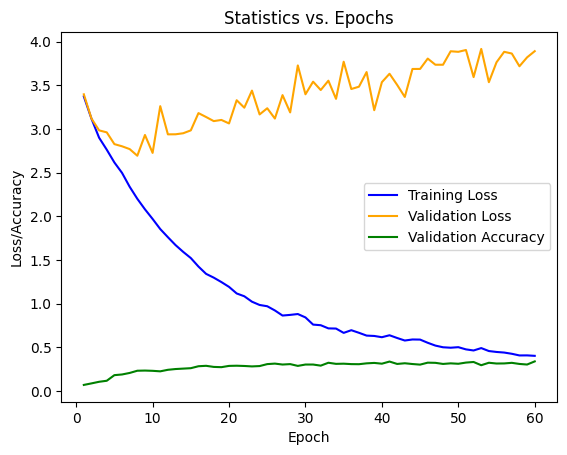

Accuracy: 34.01360544217687


In [52]:
model = BetterNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model = trainModel(model, 60)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy}")

In [41]:
model = BetterNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
model = trainModel(model, 60)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy}")

Epoch 1/60, Train Loss: 3.3024, Train Accuracy: 0.0744, Validation Loss: 3.2519, Validation Accuracy: 0.1006
Epoch 2/60, Train Loss: 2.8264, Train Accuracy: 0.1761, Validation Loss: 2.8523, Validation Accuracy: 0.1396
Epoch 3/60, Train Loss: 2.5067, Train Accuracy: 0.2423, Validation Loss: 2.6922, Validation Accuracy: 0.1797
Epoch 4/60, Train Loss: 2.2582, Train Accuracy: 0.3048, Validation Loss: 2.5029, Validation Accuracy: 0.2324
Epoch 5/60, Train Loss: 2.0653, Train Accuracy: 0.3595, Validation Loss: 2.4826, Validation Accuracy: 0.2383
Epoch 6/60, Train Loss: 1.8704, Train Accuracy: 0.4146, Validation Loss: 2.4725, Validation Accuracy: 0.2432
Epoch 7/60, Train Loss: 1.6931, Train Accuracy: 0.4600, Validation Loss: 2.4161, Validation Accuracy: 0.2754
Epoch 8/60, Train Loss: 1.4616, Train Accuracy: 0.5264, Validation Loss: 2.5524, Validation Accuracy: 0.2666
Epoch 9/60, Train Loss: 1.2881, Train Accuracy: 0.5878, Validation Loss: 2.5475, Validation Accuracy: 0.2783
Epoch 10/60, Train 

KeyboardInterrupt: 

# Data Augmentation Without Color Changing


Epoch 1/150, Train Loss: 3.4322, Train Accuracy: 0.0401, Validation Loss: 3.4106, Validation Accuracy: 0.0292
Epoch 2/150, Train Loss: 3.3176, Train Accuracy: 0.0723, Validation Loss: 3.2700, Validation Accuracy: 0.0768
Epoch 3/150, Train Loss: 3.2125, Train Accuracy: 0.0906, Validation Loss: 3.2494, Validation Accuracy: 0.0729
Epoch 4/150, Train Loss: 3.1497, Train Accuracy: 0.1097, Validation Loss: 3.1700, Validation Accuracy: 0.0982
Epoch 5/150, Train Loss: 3.0132, Train Accuracy: 0.1407, Validation Loss: 3.0310, Validation Accuracy: 0.1118
Epoch 6/150, Train Loss: 2.9020, Train Accuracy: 0.1577, Validation Loss: 3.0192, Validation Accuracy: 0.0943
Epoch 7/150, Train Loss: 2.8313, Train Accuracy: 0.1695, Validation Loss: 2.8710, Validation Accuracy: 0.1448
Epoch 8/150, Train Loss: 2.7278, Train Accuracy: 0.1895, Validation Loss: 2.8800, Validation Accuracy: 0.1244
Epoch 9/150, Train Loss: 2.6374, Train Accuracy: 0.1953, Validation Loss: 2.7046, Validation Accuracy: 0.1409
Epoch 10/1

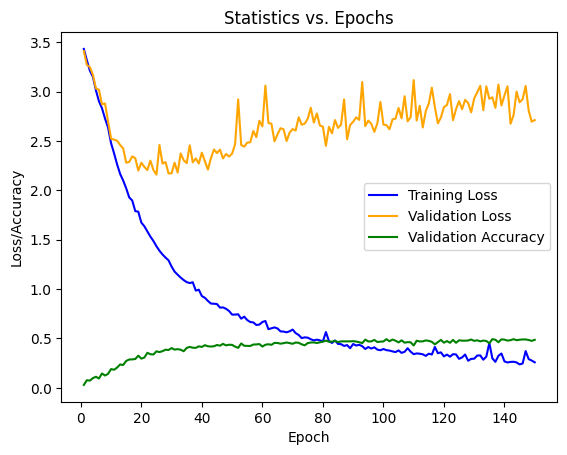

Accuracy: 48.59086491739553


In [8]:
model = BetterNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model = trainModel(model, 150)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy}")

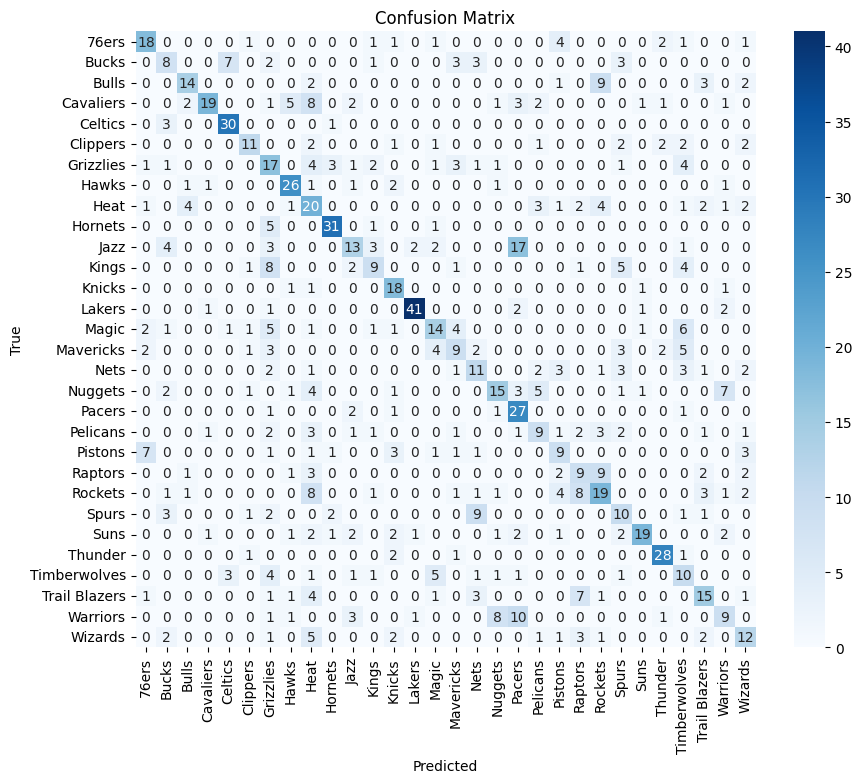

In [9]:
modelPrediction = []
realLabels = []
classNames = trainDataset.classes

with torch.no_grad():
    for inputs, labels in testLoader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        modelPrediction.extend(preds.cpu().numpy())
        realLabels.extend(labels.cpu().numpy())

cm = confusion_matrix(realLabels, modelPrediction)
labels_unique = sorted(set(classNames))

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_unique, yticklabels=labels_unique)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Data Augmentation With Color Changing

Epoch 1/200, Train Loss: 3.3983, Train Accuracy: 0.0563, Validation Loss: 3.3450, Validation Accuracy: 0.0603
Epoch 2/200, Train Loss: 3.2503, Train Accuracy: 0.0875, Validation Loss: 3.2972, Validation Accuracy: 0.0525
Epoch 3/200, Train Loss: 3.1916, Train Accuracy: 0.0919, Validation Loss: 3.2528, Validation Accuracy: 0.0622
Epoch 4/200, Train Loss: 3.1462, Train Accuracy: 0.0966, Validation Loss: 3.2054, Validation Accuracy: 0.0680
Epoch 5/200, Train Loss: 3.1243, Train Accuracy: 0.0962, Validation Loss: 3.2080, Validation Accuracy: 0.0709
Epoch 6/200, Train Loss: 3.0996, Train Accuracy: 0.0991, Validation Loss: 3.1915, Validation Accuracy: 0.0709
Epoch 7/200, Train Loss: 3.0814, Train Accuracy: 0.0974, Validation Loss: 3.2232, Validation Accuracy: 0.0622
Epoch 8/200, Train Loss: 3.0596, Train Accuracy: 0.1030, Validation Loss: 3.1449, Validation Accuracy: 0.0671
Epoch 9/200, Train Loss: 3.0346, Train Accuracy: 0.1039, Validation Loss: 3.1443, Validation Accuracy: 0.0700
Epoch 10/2

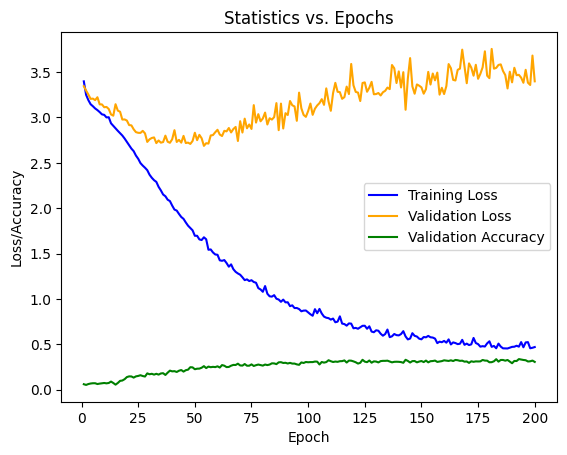

Accuracy: 30.612244897959183


In [14]:
model = BetterNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model = trainModel(model, 200)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy}")

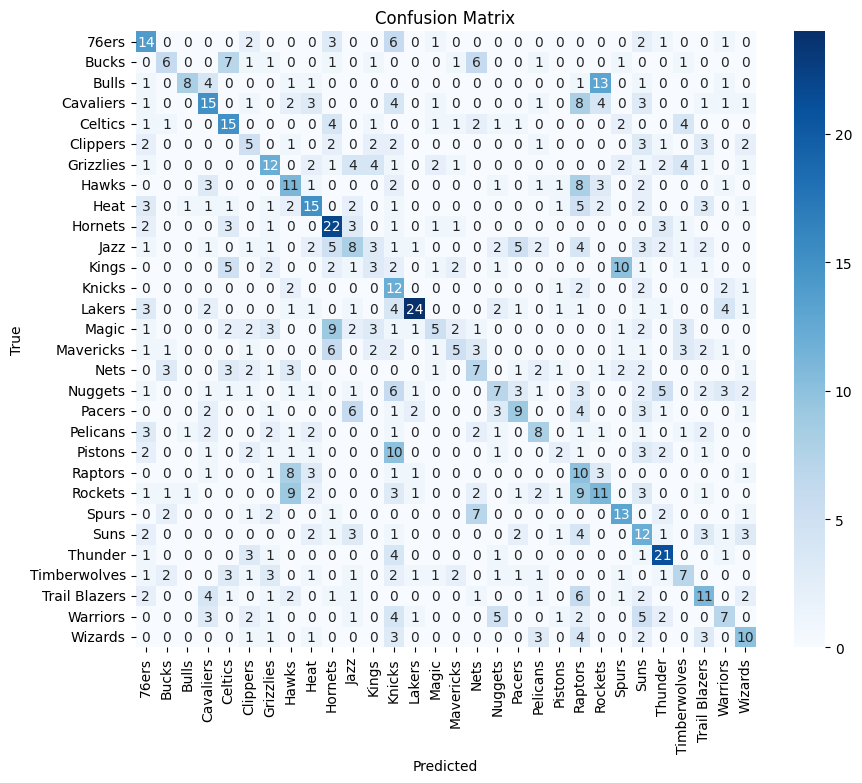

In [22]:
modelPrediction = []
realLabels = []
classNames = trainDataset.classes

with torch.no_grad():
    for inputs, labels in testLoader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        modelPrediction.extend(preds.cpu().numpy())
        realLabels.extend(labels.cpu().numpy())

cm = confusion_matrix(realLabels, modelPrediction)
labels_unique = sorted(set(classNames))

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_unique, yticklabels=labels_unique)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [7]:
model = models.resnet18()
model.fc = nn.Linear(512, 30)
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = trainModel(model, 30)
print(f"Accuracy: {evaluateModel(model, testLoader):.4f}%")

KeyboardInterrupt: 

Epoch 1/30, Train Loss: 2.8164, Train Accuracy: 0.1990, Validation Loss: 3.3682, Validation Accuracy: 0.1621
Epoch 2/30, Train Loss: 2.2197, Train Accuracy: 0.3416, Validation Loss: 3.1301, Validation Accuracy: 0.1924
Epoch 3/30, Train Loss: 2.0619, Train Accuracy: 0.3854, Validation Loss: 2.6337, Validation Accuracy: 0.2725
Epoch 4/30, Train Loss: 1.7086, Train Accuracy: 0.4871, Validation Loss: 2.3482, Validation Accuracy: 0.3135
Epoch 5/30, Train Loss: 1.4179, Train Accuracy: 0.5621, Validation Loss: 2.2393, Validation Accuracy: 0.3652
Epoch 6/30, Train Loss: 1.2815, Train Accuracy: 0.6113, Validation Loss: 2.3890, Validation Accuracy: 0.3682
Epoch 7/30, Train Loss: 1.1743, Train Accuracy: 0.6442, Validation Loss: 1.9997, Validation Accuracy: 0.4502
Epoch 8/30, Train Loss: 1.0836, Train Accuracy: 0.6714, Validation Loss: 1.8286, Validation Accuracy: 0.4941
Epoch 9/30, Train Loss: 0.9584, Train Accuracy: 0.7115, Validation Loss: 1.8215, Validation Accuracy: 0.5078
Epoch 10/30, Train 

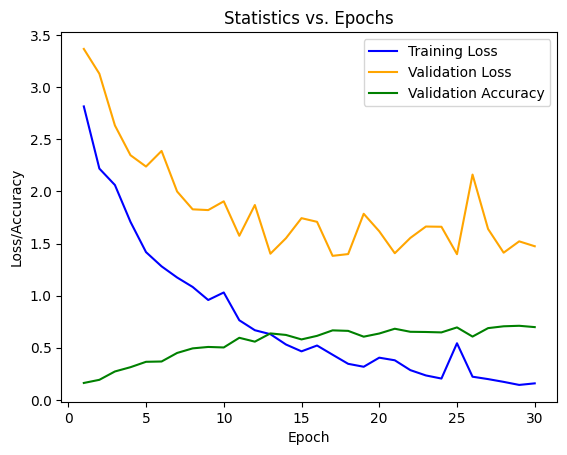

Accuracy: 69.8242%


In [8]:
model = models.resnet50()
model.fc = nn.Linear(2048, 30)
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = trainModel(model, 30)
print(f"Accuracy: {evaluateModel(model, testLoader):.4f}%")

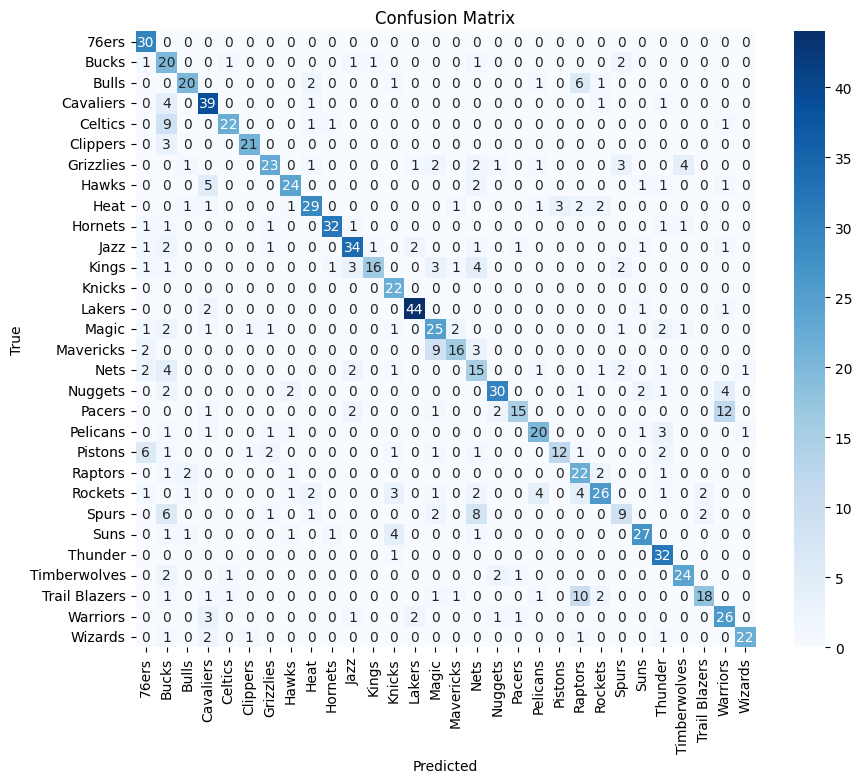

In [9]:
modelPrediction = []
realLabels = []
classNames = trainDataset.classes

with torch.no_grad():
    for inputs, labels in testLoader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        modelPrediction.extend(preds.cpu().numpy())
        realLabels.extend(labels.cpu().numpy())

cm = confusion_matrix(realLabels, modelPrediction)
labels_unique = sorted(set(classNames))

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_unique, yticklabels=labels_unique)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

Epoch 1/175, Train Loss: 3.4444, Train Accuracy: 0.0330, Validation Loss: 3.4084, Validation Accuracy: 0.0283
Epoch 2/175, Train Loss: 3.3694, Train Accuracy: 0.0427, Validation Loss: 3.3654, Validation Accuracy: 0.0508
Epoch 3/175, Train Loss: 3.2767, Train Accuracy: 0.0567, Validation Loss: 3.3009, Validation Accuracy: 0.0547
Epoch 4/175, Train Loss: 3.2128, Train Accuracy: 0.0703, Validation Loss: 3.2513, Validation Accuracy: 0.0625
Epoch 5/175, Train Loss: 3.2020, Train Accuracy: 0.0687, Validation Loss: 3.2126, Validation Accuracy: 0.0762
Epoch 6/175, Train Loss: 3.1569, Train Accuracy: 0.0769, Validation Loss: 3.1654, Validation Accuracy: 0.0850
Epoch 7/175, Train Loss: 3.1294, Train Accuracy: 0.0744, Validation Loss: 3.1374, Validation Accuracy: 0.0820
Epoch 8/175, Train Loss: 3.0378, Train Accuracy: 0.1041, Validation Loss: 3.0100, Validation Accuracy: 0.1338
Epoch 9/175, Train Loss: 2.9278, Train Accuracy: 0.1184, Validation Loss: 2.9801, Validation Accuracy: 0.1279
Epoch 10/1

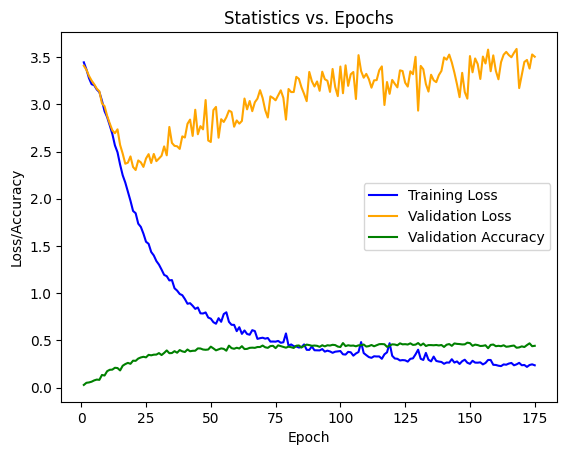

Accuracy: 44.2383%


In [48]:
model = BetterNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model = trainModel(model, 175)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy:.4f}%")

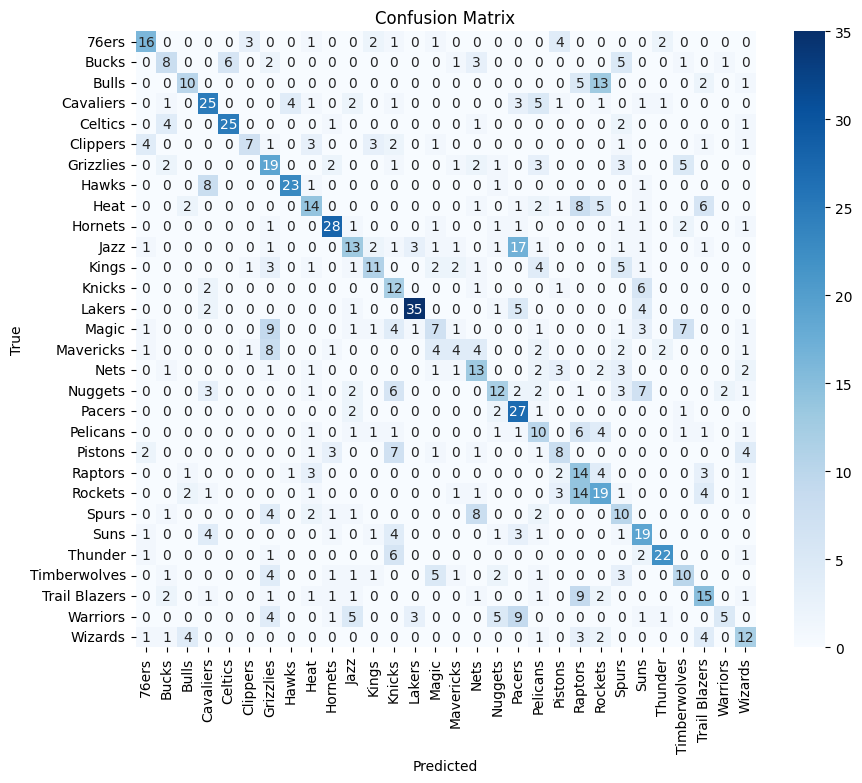

In [49]:
modelPrediction = []
realLabels = []
classNames = trainDataset.classes

with torch.no_grad():
    for inputs, labels in testLoader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        modelPrediction.extend(preds.cpu().numpy())
        realLabels.extend(labels.cpu().numpy())

cm = confusion_matrix(realLabels, modelPrediction)
labels_unique = sorted(set(classNames))

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_unique, yticklabels=labels_unique)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# EvenBetterNet

In [6]:
class ResidualBlock(nn.Module):
    def __init__(self, inChannels, outChannels, stride=1):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(inChannels, outChannels, kernel_size=3, stride=stride, padding=1),
            nn.BatchNorm2d(outChannels),
            nn.ReLU()
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(outChannels, outChannels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(outChannels)
        )

        if inChannels != outChannels or stride != 1:
            self.skip = nn.Sequential(
                nn.Conv2d(inChannels, outChannels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(outChannels)
            )
        else:
            self.skip = nn.Identity()

        self.relu = nn.ReLU()

    def forward(self, x):
        identity = self.skip(x)
        out = self.relu(self.conv1(x))
        out = self.conv2(out)
        out += identity
        return self.relu(out)


In [8]:
class EvenBetterNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = ResidualBlock(3, 16)
        self.l2 = ResidualBlock(16, 32, stride=2)
        self.l3 = ResidualBlock(32, 64, stride=2)
        
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(64, 256)
        self.fc2 = nn.Linear(256, 30)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.l1(x)
        x = self.l2(x)
        x = self.l3(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


# EvenBetterNet with .5 Dropout

Epoch 1/150, Train Loss: 2.6771, Train Accuracy: 0.2177, Validation Loss: 3.0763, Validation Accuracy: 0.1621
Epoch 2/150, Train Loss: 2.1887, Train Accuracy: 0.3387, Validation Loss: 2.4044, Validation Accuracy: 0.2617
Epoch 3/150, Train Loss: 1.9627, Train Accuracy: 0.4008, Validation Loss: 2.2603, Validation Accuracy: 0.3018
Epoch 4/150, Train Loss: 1.8029, Train Accuracy: 0.4476, Validation Loss: 2.0451, Validation Accuracy: 0.3721
Epoch 5/150, Train Loss: 1.6678, Train Accuracy: 0.4845, Validation Loss: 1.9104, Validation Accuracy: 0.3867
Epoch 6/150, Train Loss: 1.5831, Train Accuracy: 0.5126, Validation Loss: 1.8826, Validation Accuracy: 0.4053
Epoch 7/150, Train Loss: 1.4960, Train Accuracy: 0.5353, Validation Loss: 1.9337, Validation Accuracy: 0.3994
Epoch 8/150, Train Loss: 1.4238, Train Accuracy: 0.5598, Validation Loss: 1.9067, Validation Accuracy: 0.4033
Epoch 9/150, Train Loss: 1.3692, Train Accuracy: 0.5738, Validation Loss: 1.9095, Validation Accuracy: 0.4131
Epoch 10/1

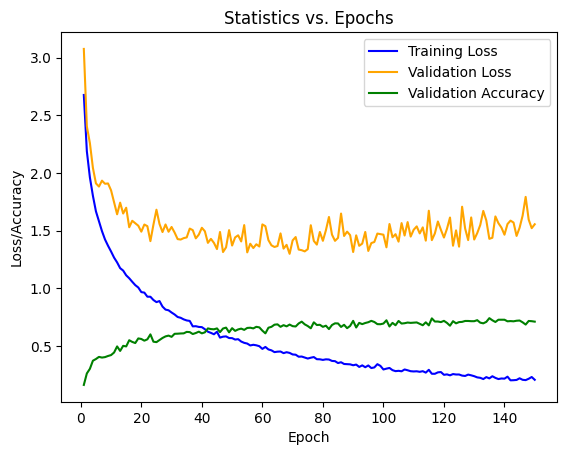

Accuracy: 71.0938%


In [23]:
model = EvenBetterNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model = trainModel(model, 150)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy:.4f}%")

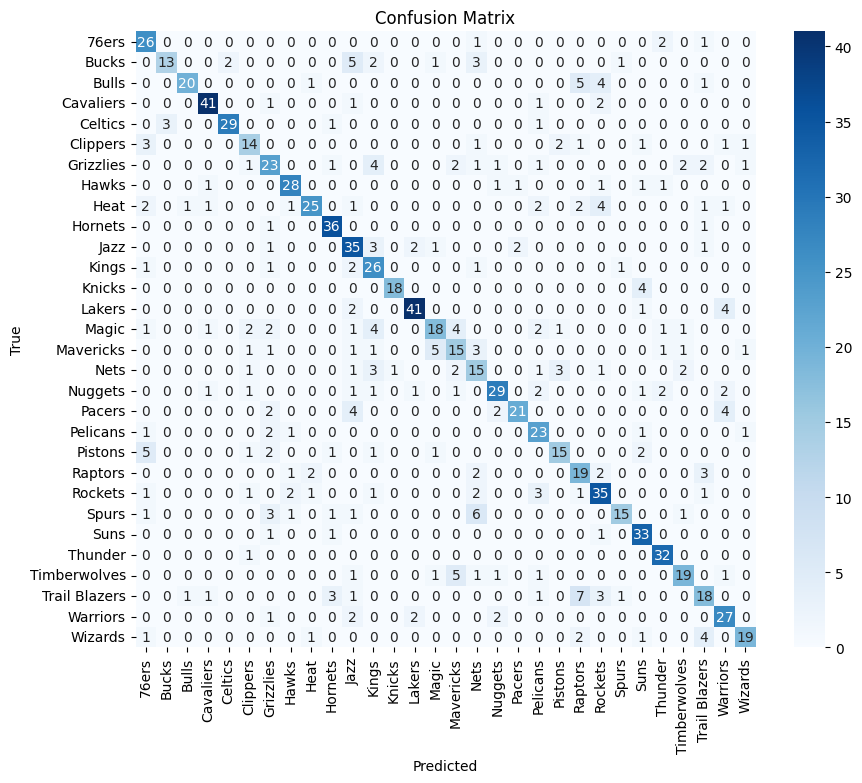

In [24]:
modelPrediction = []
realLabels = []
classNames = trainDataset.classes

with torch.no_grad():
    for inputs, labels in testLoader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        modelPrediction.extend(preds.cpu().numpy())
        realLabels.extend(labels.cpu().numpy())

cm = confusion_matrix(realLabels, modelPrediction)
labels_unique = sorted(set(classNames))

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_unique, yticklabels=labels_unique)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# EvenBetterNet with .2 Dropout

Epoch 1/150, Train Loss: 2.5370, Train Accuracy: 0.2594, Validation Loss: 2.6092, Validation Accuracy: 0.2549
Epoch 2/150, Train Loss: 2.0373, Train Accuracy: 0.3786, Validation Loss: 2.3049, Validation Accuracy: 0.2812
Epoch 3/150, Train Loss: 1.8096, Train Accuracy: 0.4466, Validation Loss: 2.2441, Validation Accuracy: 0.2998
Epoch 4/150, Train Loss: 1.6585, Train Accuracy: 0.4975, Validation Loss: 1.9812, Validation Accuracy: 0.3750
Epoch 5/150, Train Loss: 1.5229, Train Accuracy: 0.5390, Validation Loss: 2.0450, Validation Accuracy: 0.3428
Epoch 6/150, Train Loss: 1.4285, Train Accuracy: 0.5649, Validation Loss: 1.9076, Validation Accuracy: 0.4160
Epoch 7/150, Train Loss: 1.3362, Train Accuracy: 0.5965, Validation Loss: 1.7606, Validation Accuracy: 0.4316
Epoch 8/150, Train Loss: 1.2654, Train Accuracy: 0.6207, Validation Loss: 1.7264, Validation Accuracy: 0.4707
Epoch 9/150, Train Loss: 1.2151, Train Accuracy: 0.6299, Validation Loss: 1.7378, Validation Accuracy: 0.4912
Epoch 10/1

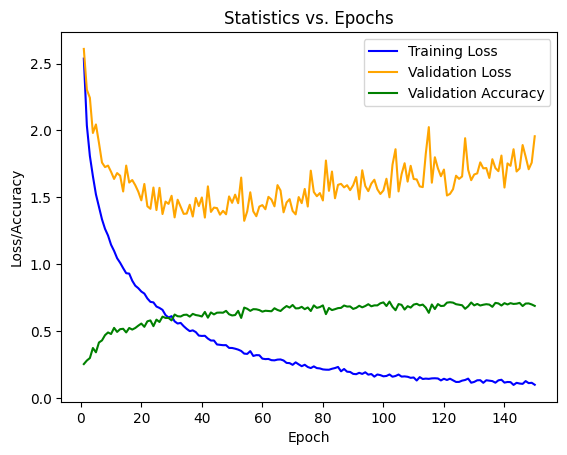

Accuracy: 68.9453%


In [9]:
model = EvenBetterNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model = trainModel(model, 150)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy:.4f}%")